## RNN- Based Sentiment Analysis of IMDb

### Objective

Develop a sentiment analysis system using a Recurrent Neural Network (RNN) that reads IMDb movie reviews and classifies them as:

* Positive 😊
* Negative 😞

The model learns the sequential relationship between words in a review and predicts its sentiment.

### Dataset

Use the IMDb Movie Reviews dataset, where each review has a sentiment label:

* 1 → Positive
* 0 → Negative

A common version contains 50,000 reviews.

### Import Libraries

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Load Dataset

In [3]:
num_words = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=num_words
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25000
Testing samples: 25000


### Padding

In [4]:
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


### Create RNN mModel

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(200,)),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 83ms/step - accuracy: 0.6787 - loss: 0.5848 - val_accuracy: 0.7636 - val_loss: 0.5009
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.8157 - loss: 0.4057 - val_accuracy: 0.6920 - val_loss: 0.5871
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9291 - loss: 0.1904 - val_accuracy: 0.7972 - val_loss: 0.5133
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.9840 - loss: 0.0529 - val_accuracy: 0.7780 - val_loss: 0.6881
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step - accuracy: 0.9973 - loss: 0.0147 - val_accuracy: 0.7744 - val_loss: 0.8139


### Training vs Validation Accuracy

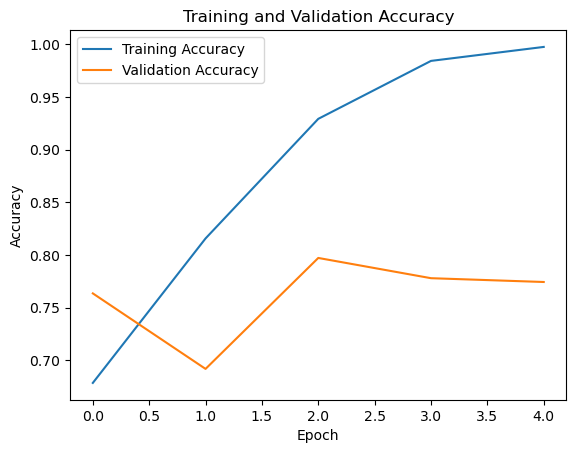

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

### Validation Loss

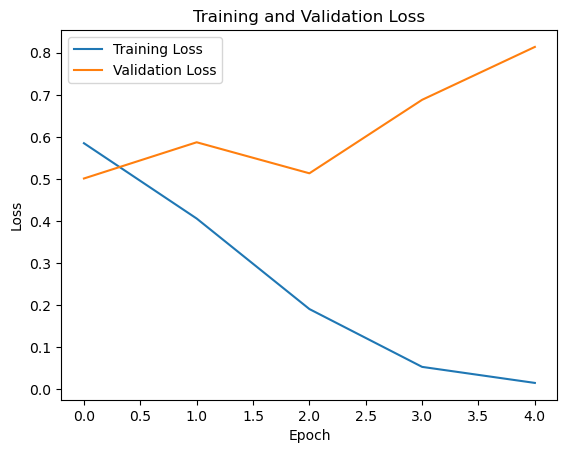

In [8]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

### Evaluate Model

In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7718 - loss: 0.8050
Test Loss: 0.8050178289413452
Test Accuracy: 0.7717599868774414


### Prediction

In [10]:
y_probability = model.predict(X_test)

y_pred = (y_probability > 0.5).astype(int)

y_pred = y_pred.flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step


### Classification Metrics

In [11]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.77176
Precision: 0.7570758286665658
Recall   : 0.80032
F1 Score : 0.7780975344170491


### Classification Report

In [12]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.79      0.74      0.77     12500
    Positive       0.76      0.80      0.78     12500

    accuracy                           0.77     25000
   macro avg       0.77      0.77      0.77     25000
weighted avg       0.77      0.77      0.77     25000



### Confusion Matrix

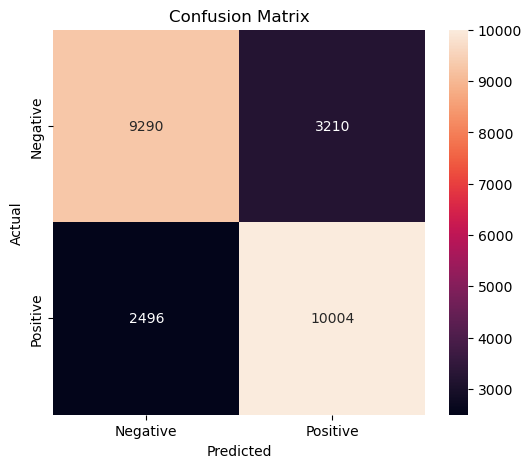

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Test a New Review

In [14]:
word_index = imdb.get_word_index()

def predict_sentiment(review):

    words = review.lower().split()

    encoded_review = []

    for word in words:
        if word in word_index:
            encoded_review.append(
                word_index[word] + 3
            )
        else:
            encoded_review.append(2)

    padded_review = pad_sequences(
        [encoded_review],
        maxlen=200
    )

    probability = model.predict(
        padded_review,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, probability

### Give Own Review

In [15]:
review = "This movie was boring, terrible and disappointing"

sentiment, probability = predict_sentiment(review)

print("Review:", review)
print("Sentiment:", sentiment)
print("Confidence:", round((1 - probability) * 100, 2), "%")

Review: This movie was boring, terrible and disappointing
Sentiment: Negative
Confidence: 99.99 %


In [16]:
word_index = imdb.get_word_index()

def predict_sentiment(review):
    x = [word_index.get(w, 2) + 3 for w in review.lower().split()]
    x = pad_sequences([x], maxlen=200)
    p = model.predict(x, verbose=0)[0][0]
    return ("Positive" if p >= 0.5 else "Negative"), p

review = "This movie was amazing and I really loved it"
sentiment, p = predict_sentiment(review)

print("Review:", review)
print("Sentiment:", sentiment)
print("Confidence:", round(p * 100, 2), "%")

Review: This movie was amazing and I really loved it
Sentiment: Positive
Confidence: 97.75 %


### Conclusion

The RNN-based sentiment analysis system successfully classified IMDb movie reviews into positive and negative sentiments. By learning the sequential relationships between words, the RNN was able to understand important patterns in movie reviews. The model was evaluated using accuracy, precision, recall, F1-score, and confusion matrix. This project demonstrates how Recurrent Neural Networks can be effectively used for text classification and sentiment analysis.